# 마켓컬리 신선식품 리뷰

신선식품 리뷰 내 맛·품질·신선도·배송 평가축 차이 확인
API 수집 리뷰 → 상품·카테고리 보강 → 키워드 분류 → LLM 검증 → 운영 우선순위 정리


### 1. 데이터 로드

CSV 4종: `df_raw` 원본 수집본, `df` 4축·감성 분석본, `name_df` 상품명 보강본, `df_llm` LLM 검증본
원본 우선 확인, 산출물 CSV는 사용 구간별 순차 로드


In [1]:
# 기본 라이브러리
import os
import re
import time
import warnings
import requests
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from kiwipiepy import Kiwi
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

# 한글 폰트
font_path = 'C:/Windows/Fonts/malgun.ttf'
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', 50)

# 원본 리뷰 수집본
# API 수집 원천 데이터, 상품명 보강 시작점
df_raw = pd.read_csv('kurly_reviews_raw.csv', encoding='utf-8-sig')
df_raw['product_no'] = df_raw['product_no'].astype(str).str.split('.').str[0]


C:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# 원본 크기: trim 완료 리뷰 6,441건 기준
df_raw.shape

(6441, 5)

In [3]:
# 4축·감성 분류본
# 기존 분류 결과 확인용
df = pd.read_csv('kurly_reviews_classified.csv', encoding='utf-8-sig')
df['product_no'] = df['product_no'].astype(str)
df['registered_at'] = pd.to_datetime(df['registered_at'], errors='coerce')

# 분류본 크기: 4축·감성 라벨 포함 분석본 기준
df.shape


(6441, 22)

In [4]:
# LLM 검증 저장본
# 저장 검증 결과 확인용
df_llm = pd.read_csv('kurly_reviews_llm_validation.csv', encoding='utf-8-sig') if os.path.exists('kurly_reviews_llm_validation.csv') else None

# LLM 검증본 크기: 저장 검증 CSV 기준
df_llm.shape if df_llm is not None else None


(6441, 9)

In [5]:
# 카테고리 분포: 6개 신선식품 표본 구성 확인
df['category'].value_counts()

category
토마토      2000
소고기등심    1800
사과        962
딸기        643
생연어       636
계란        400
Name: count, dtype: int64

In [6]:
# 감성 분포: 긍정·중립·부정 라벨 비중 확인
df['sentiment'].value_counts()

sentiment
긍정    4354
중립    1806
부정     281
Name: count, dtype: int64

In [7]:
# 원본 컬럼: 수집 원본 컬럼 구조 확인
df_raw.columns.tolist()

['product_no', 'review_text', 'segment', 'registered_at', 'source']

In [8]:
# 원본 샘플: 리뷰 원문과 상품번호 형태 확인
df_raw.head(3)

,product_no,review_text,segment,registered_at,source
0,5061259,아침마다 감탄하며 먹고있는 홍로 사과!!🍎\n이름 그대로 불그스름하고 예쁘게 익은 홍로사과가\n상처없이 잘 포장되서 왔구요~~♡♡\n홍로 사과의 특징이 아삭한 식감과 당도가...,과일,NaN,NaN
1,5061259,이렇게 예쁘고 고운 사과를 편히 받아 볼 수 있어 감사합니다. 깨끗이 씻어서 남편 새벽 도시락에 싸주었어요💛,과일,NaN,NaN
2,5061259,사과가 요즘 금값이라 \n아껴서 먹곤 하는데\n마켓컬리 고랭지 햇사과 5개입 중 \n하나는 실패고 나머지는 괜찮았어요!\n크기는 소~ 중과 정도에 따라서 갯수가 정해지는듯 ...,과일,NaN,NaN


### 2. 상품 매핑

상품번호 기준 6개 카테고리 연결
토마토만 일반·방울·스테비아 세부 유형 분리


In [9]:
# 상품번호 매핑
apple_list = ['5061259','1001303421','1000122762','5005943','1000908371','1001882653',
         '5049096','1000065953','1001847779','1000343040','1000914411','5030220',
         '5060606','1000873951','1001811209']

# 상품군 리스트
strawberry_list = ['5048935','1000350168','1000942891','5065323','1001848684','5062680',
              '5106292','5065480','1001801374','1001801376','1001801377','1001801382',
              '1001801369','5035027','1001801367','1001801372','1001801375','1001801379']

beef_list = ['5055607','1001335683','5010944','5054439','5067015','5103614','5051043',
        '1000433103','1001201257','5054430','5037694','5052551','5009479','5065334',
        '5051046','1000669892','1001351875','1000892007','5062534','1000630278',
        '1001249381','5043074','1000662115','1001251426','5050080','5090106',
        '1000892003','1000892005','5006172','5055609','5054441','5059981','5057636']

salmon_list = ['1000750847','1000636870','1000636872','5138716','1000165819','5053884',
          '5066649','1000636875','1000612746','1001451412']

tomato_map = {
    '5063690':'일반','5063578':'방울','5066038':'일반','5029438':'방울',
    '5000100':'일반','1001234463':'방울+스테비아','1000365252':'스테비아',
    '1000147414':'방울','1000357035':'일반','1000376854':'방울','5136653':'일반',
    '5006032':'일반','5029436':'일반','5067909':'일반','1000537255':'방울+스테비아',
    '5049265':'방울','5031060':'일반','5063866':'일반','1000956901':'방울',
    '5049245':'일반','5157163':'방울','1001392267':'방울','1000127040':'방울',
    '5000099':'방울','1001188148':'일반','1000220028':'방울','1000973395':'방울',
    '5063864':'방울','1000479067':'방울','1001971868':'일반','1001881389':'방울',
    '5002974':'일반','1001495528':'방울+스테비아','5132941':'일반','1001137981':'방울',
    '1002034192':'방울','1001341778':'일반','1001971858':'방울'
}

egg_list = ['5056791','5029850','1000127449','5151849','5151851','1000179412','5031086',
       '5119904','5151848','1001058180','1000206115','5119903','1000050986',
       '1001293819','5029849','5115293','5004951','1000363410','1000137054',
       '1001478560','1001478558','5093936','5038290','5034943','1001703856',
       '5053113','5155499','5138999','1001998058','1001998060','1001478556',
       '1000318940','1001971302','5031099','5152664','1000378376','5056790',
       '5050055','5067039','1001365218','1001995045','1001365220','5041405',
       '5038008','5054981','1001693706','5078347','5099478','5067038',
       '1001384001','5000093','1001384003']

# 매핑 테이블
category_map, subtype_map = {}, {}
for product_no in apple_list:      category_map[product_no]='사과';       subtype_map[product_no]='일반'
for product_no in strawberry_list: category_map[product_no]='딸기';       subtype_map[product_no]='일반'
for product_no in beef_list:       category_map[product_no]='소고기등심'; subtype_map[product_no]='일반'
for product_no in salmon_list:     category_map[product_no]='생연어';     subtype_map[product_no]='일반'
for product_no in egg_list:        category_map[product_no]='계란';       subtype_map[product_no]='일반'
for product_no, tomato_type in tomato_map.items():
    category_map[product_no]='토마토'; subtype_map[product_no]=tomato_type

In [10]:
# 매핑 상품 수: 상품번호 매핑 대상 164개 기준
len(category_map)

166

In [11]:
# 카테고리 목록: 6개 분석 카테고리 유지
sorted(set(category_map.values()))

['계란', '딸기', '사과', '생연어', '소고기등심', '토마토']

In [12]:
# 토마토 세부 유형: 일반·방울·스테비아 구분
sorted(set(tomato_map.values()))

['방울', '방울+스테비아', '스테비아', '일반']

매핑 누락: 상품번호 기준 매핑 정상 여부 확인


In [13]:
# 매핑 적용
df_raw['category'] = df_raw['product_no'].map(category_map)
df_raw['subtype']  = df_raw['product_no'].map(subtype_map)

# 누락 확인
missing = df_raw[df_raw['category'].isna()]
if len(missing) > 0:
    display(missing['product_no'].unique())
else:
    display('mapping ok')

# 카테고리 분포
df_raw.groupby('category').size().sort_values(ascending=False)

'mapping ok'

category
토마토      2000
소고기등심    1800
사과        962
딸기        643
생연어       636
계란        400
dtype: int64

상품명 보강: 기존 보강본 우선, 누락 상품만 API 재조회


In [14]:
# 상품명 보강
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
unique_products = df_raw['product_no'].unique()

# 기존 상품명
name_map = {}

if 'product_name' in df.columns:
    name_map.update(df.dropna(subset=['product_name']).set_index('product_no')['product_name'].to_dict())

if os.path.exists('kurly_reviews_product_name.csv'):
    # 상품명 보강본
    saved_names = pd.read_csv('kurly_reviews_product_name.csv', encoding='utf-8-sig')
    if 'product_name' in saved_names.columns:
        saved_names['product_no'] = saved_names['product_no'].astype(str)
        name_map.update(saved_names.dropna(subset=['product_name']).set_index('product_no')['product_name'].to_dict())

# 누락 상품
missing_products = [product_no for product_no in unique_products if product_no not in name_map]

# API 보강
if missing_products:
    for i, product_no in enumerate(missing_products, 1):
        url = f'https://api.kurly.com/showroom/v2/products/{product_no}'
        name = None
        try:
            r = requests.get(url, headers=headers, timeout=10)
            if r.status_code == 200:
                name = r.json().get('data', {}).get('name')
        except Exception:
            pass
        if name:
            name_map[product_no] = name
        time.sleep(1.0)

# 상품명 매핑
df_raw['product_name'] = df_raw['product_no'].map(name_map)

pd.Series({
    '전체 상품': len(unique_products),
    '기존 상품명': len(name_map),
    '신규 수집 대상': len(missing_products),
    '상품명 매핑 성공': df_raw['product_name'].notna().sum(),
})

전체 상품         121
기존 상품명        121
신규 수집 대상        0
상품명 매핑 성공    6441
dtype: int64

파생 컬럼: 리뷰 길이·등록월 생성, 보강본 저장 기준 고정 / 품절·판매중단·상품명 변경 가능성 대응


In [15]:
# 파생 변수
# 상품명·등록월 고정
# 텍스트·날짜 정리
df_raw['review_text']   = df_raw['review_text'].fillna('').astype(str)
df_raw['review_length'] = df_raw['review_text'].str.strip().str.len()
df_raw['registered_at'] = pd.to_datetime(df_raw['registered_at'], errors='coerce')
df_raw['year_month']    = df_raw['registered_at'].dt.to_period('M').astype(str)

# 상품명 누락 대비
if 'product_name' not in df_raw.columns:
    df_raw['product_name'] = None
    print('product_name 없음')

# 컬럼 순서
cols_order = ['product_no','segment','category','subtype','product_name',
              'review_text','review_length','registered_at','year_month']
cols_order = [c for c in cols_order if c in df_raw.columns]
extra = [c for c in df_raw.columns if c not in cols_order]
df_raw = df_raw[cols_order + extra]

# 보강본 저장
df_raw.to_csv('kurly_reviews_product_name.csv', index=False, encoding='utf-8-sig')

df_raw.shape

(6441, 10)

In [16]:
# 보강본 샘플: 상품명·카테고리·등록월 반영 확인
df_raw.head(3)

,product_no,segment,category,subtype,product_name,review_text,review_length,registered_at,year_month,source
0,5061259,과일,사과,일반,고랭지 사과 1.3kg,아침마다 감탄하며 먹고있는 홍로 사과!!🍎\n이름 그대로 불그스름하고 예쁘게 익은 홍로사과가\n상처없이 잘 포장되서 왔구요~~♡♡\n홍로 사과의 특징이 아삭한 식감과 당도가...,316,NaT,NaN,NaN
1,5061259,과일,사과,일반,고랭지 사과 1.3kg,이렇게 예쁘고 고운 사과를 편히 받아 볼 수 있어 감사합니다. 깨끗이 씻어서 남편 새벽 도시락에 싸주었어요💛,60,NaT,NaN,NaN
2,5061259,과일,사과,일반,고랭지 사과 1.3kg,사과가 요즘 금값이라 \n아껴서 먹곤 하는데\n마켓컬리 고랭지 햇사과 5개입 중 \n하나는 실패고 나머지는 괜찮았어요!\n크기는 소~ 중과 정도에 따라서 갯수가 정해지는듯 ...,311,NaT,NaN,NaN


보강 결과: 카테고리별 리뷰 수와 평균 길이 확인


In [17]:
# 세그먼트 요약
summary = df_raw.groupby(['segment','category','subtype']).agg(
    review_count=('review_text','count'),
    product_count=('product_no','nunique'),
    avg_length=('review_length','mean'),
).round(1).reset_index()
summary

,segment,category,subtype,review_count,product_count,avg_length
0,계란,계란,일반,400,8,62.0
1,과일,딸기,일반,643,17,39.7
2,과일,사과,일반,962,15,42.7
3,수산,생연어,일반,636,10,46.1
4,육류,소고기등심,일반,1800,33,44.8
5,채소,토마토,방울,943,18,45.2
6,채소,토마토,방울+스테비아,147,3,48.7
7,채소,토마토,스테비아,59,1,43.9
8,채소,토마토,일반,851,16,43.9


In [18]:
# 분석본 크기: 분류 완료 데이터 행·열 확인
df.shape

(6441, 22)

In [19]:
# 상품 수: 상품번호 기준 고유 상품 수 확인
df['product_no'].nunique()

121

In [20]:
# 카테고리 수: 6개 분석 카테고리 유지
df['category'].nunique()

6

In [21]:
# 기간 범위: 등록일 기준 분석 기간 확인
pd.Series([df['registered_at'].min(), df['registered_at'].max()], index=['min', 'max'])

min   2021-12-25 11:51:59
max   2026-04-13 19:16:16
dtype: datetime64[us]

In [22]:
# 리뷰 길이 통계: 중앙값과 이상치 범위 확인
df[['review_length']].describe().round(1)

,review_length
count,6441.0
mean,45.2
std,87.9
min,7.0
25%,16.0
50%,23.0
75%,38.0
max,1299.0


### 3. 리뷰 구조

리뷰 길이, 카테고리 분포, 월별 등록 추이 확인
카테고리별 표본 차이와 텍스트 길이 편차 점검


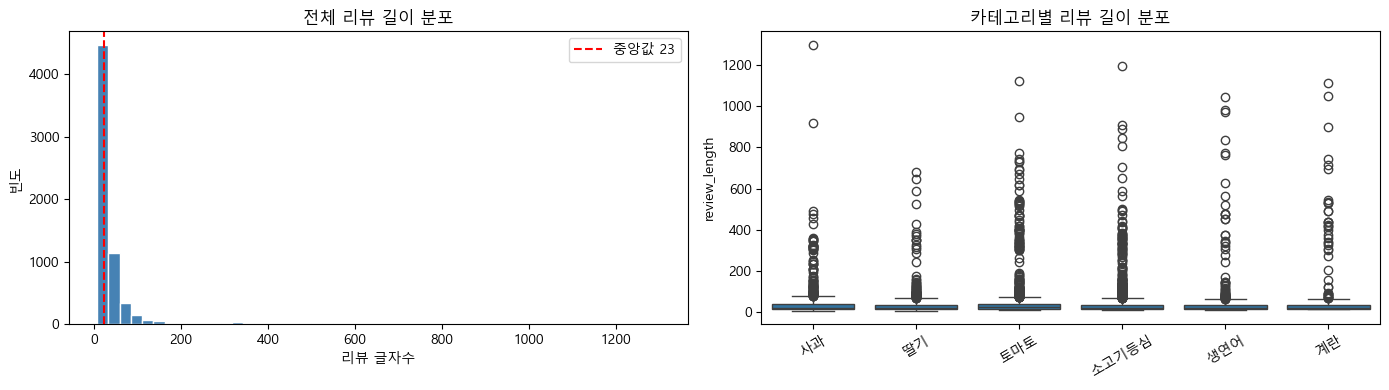

In [23]:
# 리뷰 길이 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 길이
axes[0].hist(df['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['review_length'].median(), color='red', linestyle='--',
                label=f'중앙값 {df["review_length"].median():.0f}')
axes[0].set_xlabel('리뷰 글자수'); axes[0].set_ylabel('빈도')
axes[0].set_title('전체 리뷰 길이 분포'); axes[0].legend()

# 카테고리별 길이
order = ['사과','딸기','토마토','소고기등심','생연어','계란']
sns.boxplot(data=df, x='category', y='review_length', ax=axes[1], order=order)
axes[1].set_title('카테고리별 리뷰 길이 분포'); axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()


In [24]:
# 카테고리별 길이: 평균·중앙값·편차 비교
df.groupby('category')['review_length'].agg(['mean','median','std']).round(1)

,mean,median,std
category,,,
계란,62.0,23.0,136.0
딸기,39.7,21.0,67.6
사과,42.7,22.0,77.2
생연어,46.1,21.0,107.4
소고기등심,44.8,23.0,80.7
토마토,44.9,24.0,85.3


카테고리 분포: 카테고리와 세부 유형별 리뷰 수 비교


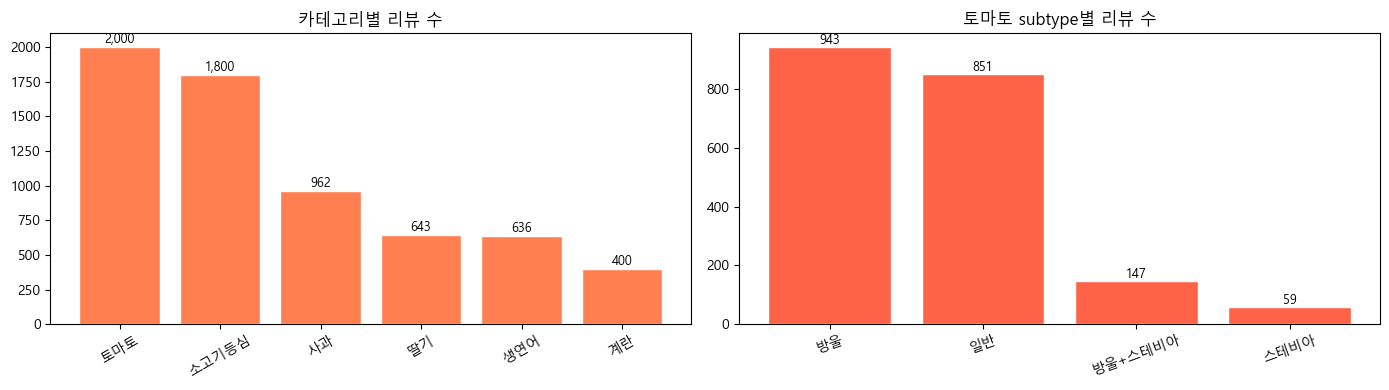

In [25]:
# 카테고리·세부 유형 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 카테고리 리뷰 수
cat_counts = df.groupby('category').size().sort_values(ascending=False)
axes[0].bar(cat_counts.index, cat_counts.values, color='coral', edgecolor='white')
axes[0].set_title('카테고리별 리뷰 수'); axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v+30, f'{v:,}', ha='center', fontsize=9)

# 토마토 세부 유형
tomato_reviews = df[df['category']=='토마토'].groupby('subtype').size().sort_values(ascending=False)
axes[1].bar(tomato_sub.index, tomato_sub.values, color='tomato', edgecolor='white')
axes[1].set_title('토마토 subtype별 리뷰 수'); axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(tomato_sub.values):
    axes[1].text(i, v+10, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout(); plt.show()

월별 추이: 등록월 기준 리뷰 수집 분포 확인


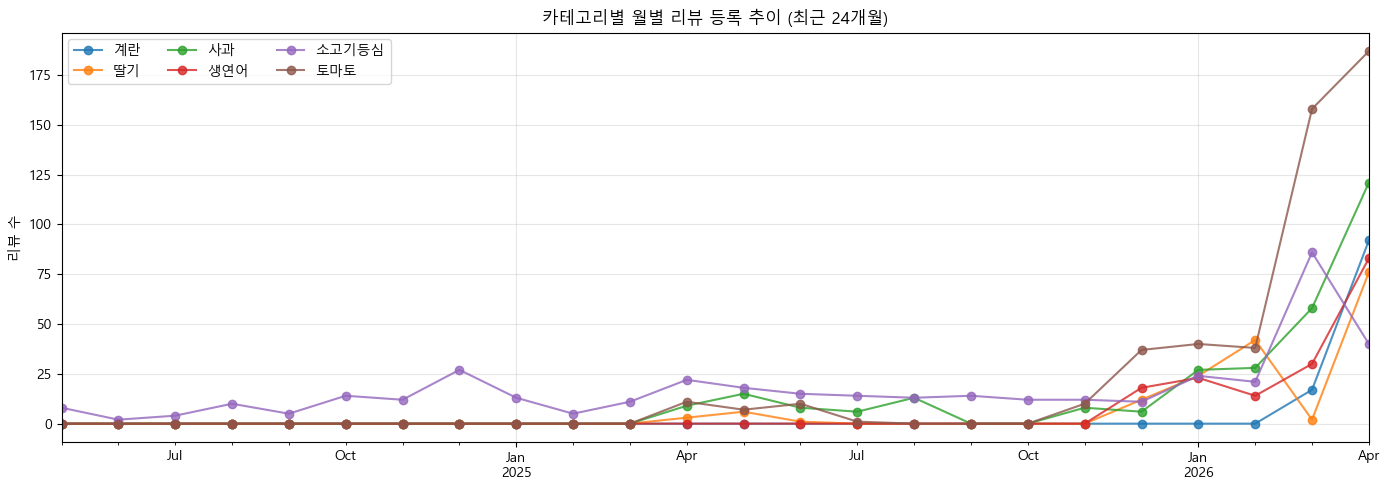

In [26]:
# 월별 리뷰 추이
monthly = df.dropna(subset=['registered_at']).groupby(
    [df['registered_at'].dt.to_period('M'), 'category']
).size().unstack(fill_value=0)
# 최근 24개월
monthly.index = monthly.index.to_timestamp()
monthly = monthly.sort_index().tail(24)

# 추이 시각화
fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax, marker='o', linewidth=1.5, alpha=0.8)
ax.set_title('카테고리별 월별 리뷰 등록 추이 (최근 24개월)')
ax.set_ylabel('리뷰 수'); ax.set_xlabel('')
ax.legend(loc='upper left', ncol=3); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

빈출어: 카테고리별 반복 표현 차이 확인 / 맛·신선도·배송 관련 표현 분리 여부 점검


In [27]:
# 형태소 분석 기준
kiwi = Kiwi()
# 불용어
stopwords = {
    '있다','하다','되다','같다','없다','이다','아니다',
    '좋다','나쁘다','많다','적다','그렇다','이렇다','저렇다',
    '것','수','등','및','때','게','거','지','걸','줄','데',
    '점','한','두','번','주','때문','경우','정말','진짜','너무','아주','매우','그냥',
    '리뷰','상품','제품','구매','주문','받다','시키다','먹다','사다','오다','가다','보다','주다','나오다',
    '하나','여러','저희','우리','마켓','컬리','마켓컬리','배송','항상','계속','자주','이번','이제','조금',
    '약간','생각','느낌','정도','부분','마음','기분','사람','아이','가족','애기','처음','예전',
    '요즘','다시','추천','감사','최고','만족'
}

# 명사 토큰

def tokenize_korean(text):
    if not isinstance(text, str) or not text.strip():
        return []
    tokens = kiwi.tokenize(text)
    return [t.form for t in tokens
            if t.tag.startswith(('NN'))
            and len(t.form) >= 2
            and t.form not in stopwords]

# 키워드 빈도

def get_keyword_freq(reviews, top_n=50):
    tokens = []
    for text in reviews:
        tokens.extend(tokenize_korean(text))
    return dict(Counter(tokens).most_common(top_n))

# 카테고리별 빈출어
STOP = {'너무','정말','진짜','그냥','좀','항상','매번','자주','계속','다시','이번','이제',
        '있어요','있네요','해요','했어요','했는데','하는데','해서','되어','되네요',
        '같아요','같네요','받았','받았어요','시켜','시켰','먹어','먹었','먹고','먹는',
        '구매','주문','생각','느낌','근데','그리고','그래서','그런데','하지만','때문',
        '것','수','거','게','건','지','더','아주','매우','많이','조금','약간','바로'}

# 공백 토큰
def tokenize(text):
    text = re.sub(r'[^\w가-힣\s]', ' ', str(text))
    return [t for t in text.split() if len(t) >= 2 and not t.isdigit() and t not in STOP]

# 카테고리별 빈도
freq_rows = []
for category in ['사과','딸기','토마토','소고기등심','생연어','계란']:
    reviews = df[df['category']==category]
    all_tokens = [tok for txt in reviews['review_text'] for tok in tokenize(txt)]
    for word, count in Counter(all_tokens).most_common(10):
        freq_rows.append({'category': category, 'word': word, 'count': count})

pd.DataFrame(freq_rows)

,category,word,count
0,사과,사과,231
1,사과,맛있어요,159
2,사과,사과가,99
3,사과,좋아요,89
4,사과,달고,58
5,사과,아삭하고,52
6,사과,맛도,47
7,사과,맛은,47
8,사과,맛이,46
9,사과,사과를,44


### 4. 키워드 분류

맛·품질·신선도·배송 4축 키워드 사전 적용
긍정·부정 단어 기반 감성 라벨 재생성


In [28]:
# 4축 키워드
axis_keywords = {
    '맛': ['맛있','맛나','달','달콤','달달','새콤','시원','시큼','쓴','짭','짜','고소',
            '풍미','향','감칠맛','식감','쫀득','부드럽','질김','질겨','꿀맛','싱겁','담백',
            '당도','산미','향긋','기름기','마블링','육즙','쫄깃','느끼'],
    '품질': ['크기','크다','작다','작은','큰','실하','알차','등급','1+','1++','한우',
              '국산','원산지','흠집','상처','멍','벌레','이물','곰팡이','가격','저렴',
              '비싸','가성비','값어치','품질','퀄리티','모양','색','색감','때깔'],
    '신선도': ['신선','싱싱','무르','물렁','짓무','상했','상한','변질','쉰','썩','곰팡',
                '시들','유통기한','유통','임박','날짜','생기','팔팔','살아있','비린','비림',
                '비린내','상함','신선도','생생','살아'],
    '배송': ['배송','새벽','포장','박스','아이스팩','드라이아이스','보냉','깨','파손',
              '부러','흐르','새','샘','터짐','터져','찢','찌그','도착','받았','온도',
              '미지근','따뜻','차갑','택배','기사님','스티로폼','냉동','냉장']
}

# 감성 단어
positive_words = ['좋','만족','최고','맛있','추천','굿','완벽','훌륭','신선','싱싱','대박',
                   '감동','재구매','또 시킬','또시킬','다시 시킬','사랑','기대 이상','쵝오',
                   '짱','예뻐','예쁘','깔끔','잘','빠르','친절','시원','감사','꿀']
negative_words = ['별로','실망','아쉬','비싸','비쌈','상했','상함','곰팡','썩','짓무','무르',
                   '물렁','쉰','변질','파손','깨짐','깨져','터짐','터져','찌그','환불','반품',
                   '나쁨','최악','불쾌','역겨','비린','느끼','질김','질겨','실망','안 좋']

# 사전 크기
pd.Series({
    '맛': len(axis_keywords['맛']),
    '품질': len(axis_keywords['품질']),
    '신선도': len(axis_keywords['신선도']),
    '배송': len(axis_keywords['배송']),
    '긍정': len(positive_words),
    '부정': len(negative_words),
})

맛      31
품질     30
신선도    26
배송     28
긍정     29
부정     32
dtype: int64

분류 적용: 리뷰별 4축·감성 라벨 재생성


In [29]:
# 보강본 컬럼 정리
# 상품명 보강본
name_df = pd.read_csv('kurly_reviews_product_name.csv', encoding='utf-8-sig')

# 기존 라벨 제거
# 보존 컬럼
clean_cols = [col for col in name_df.columns 
              if not any(col.startswith(prefix) for prefix in ['axis_', 'hits_'])
              and col not in ['sentiment', 'pos_hits', 'neg_hits', 'axis_total']]

# 보강본 저장
name_df = name_df[clean_cols]
name_df.to_csv('kurly_reviews_product_name.csv', index=False, encoding='utf-8-sig')
print('보강본 정리 완료')
print(name_df.columns.tolist())

보강본 정리 완료
['product_no', 'segment', 'category', 'subtype', 'product_name', 'review_text', 'review_length', 'registered_at', 'year_month', 'source']


In [30]:
# 4축·감성 라벨
# 라벨링 함수
def classify_review(text):
    label = {}
    for axis, words in axis_keywords.items():
        hit_count = sum(1 for word in words if word in text)
        label[f'axis_{axis}'] = 1 if hit_count > 0 else 0
        label[f'hits_{axis}'] = hit_count

    # 감성 점수
    positive_count = sum(1 for word in positive_words if word in text)
    negative_count = sum(1 for word in negative_words if word in text)
    label['sentiment'] = '긍정' if positive_count > negative_count else ('부정' if negative_count > positive_count else '중립')
    label['pos_hits'] = positive_count
    label['neg_hits'] = negative_count
    return label

# 상품명·등록월 보강본
# 4축·감성 라벨 재생성 기준 데이터
df = pd.read_csv('kurly_reviews_product_name.csv', encoding='utf-8-sig')
df['review_text'] = df['review_text'].fillna('').astype(str)

# 라벨 적용
labels = df['review_text'].apply(classify_review)
label_df = pd.DataFrame(list(labels))

# 기존 라벨 제거
old_label_cols = [col for col in label_df.columns if col in df.columns]
if old_label_cols:
    df = df.drop(columns=old_label_cols)

# 라벨 결합
df = pd.concat([df, label_df], axis=1)
df['axis_total'] = df[[f'axis_{a}' for a in ['맛','품질','신선도','배송']]].sum(axis=1)

# 분류본 저장
df.to_csv('kurly_reviews_classified.csv', index=False, encoding='utf-8-sig')

pd.Series({
    'rows': len(df),
    'axis_unmapped': (df['axis_total'] == 0).sum(),
    'axis_unmapped_pct': round((df['axis_total'] == 0).mean() * 100, 1),
})


rows                 6441.0
axis_unmapped        1834.0
axis_unmapped_pct      28.5
dtype: float64

In [31]:
# 미분류 리뷰 샘플
unmapped_samples = df[df['axis_total'] == 0]['review_text'].dropna().sample(3, random_state=42)
pd.Series([text.replace('\n', ' ')[:80] + ('...' if len(text) > 80 else '') for text in unmapped_samples])

0            생각보다 기름이 많네요 좀...
1    앙증맞고 맛도 좋음. 하나로는 쬐끔 부족 ㅋㅋ
2      꽃등심은 처음 시켜보는데 기대가 됩니다!!
dtype: str

중복 컬럼: 재분류 후 컬럼 중복 확인


In [32]:
dup = [c for c in df.columns if list(df.columns).count(c) > 1]
set(dup) if dup else 'dup ok'

'dup ok'

In [33]:
# 분류본 컬럼 수: 최종 분석 컬럼 구성 확인
len(df.columns)

22

In [34]:
# 분류본 행 수: 재분류 후 행 수 유지 확인
len(df)

6441

In [35]:
# 분류 라벨 샘플: 4축·감성 라벨 결과 확인
df[['axis_맛','axis_품질','axis_신선도','axis_배송','sentiment']].head(3)

,axis_맛,axis_품질,axis_신선도,axis_배송,sentiment
0,1,1,0,1,긍정
1,0,0,0,1,긍정
2,1,1,1,1,긍정


### 5. 평가축 비교

전체 축 커버리지와 카테고리별 언급률 확인
과일 맛·품질, 연어 신선도, 계란 배송 이슈 구조 확인


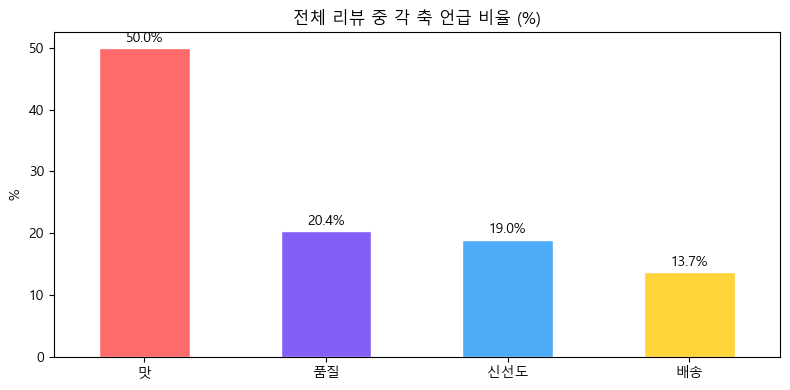

In [36]:
# 평가축 커버리지
coverage = pd.Series({a: df[f'axis_{a}'].mean()*100 for a in ['맛','품질','신선도','배송']})

fig, ax = plt.subplots(figsize=(8, 4))
coverage.plot(kind='bar', color=['#ff6b6b','#845ef7','#4dabf7','#ffd43b'], edgecolor='white', ax=ax)
ax.set_title('전체 리뷰 중 각 축 언급 비율 (%)'); ax.set_ylabel('%')
for i, v in enumerate(coverage.values):
    ax.text(i, v+1, f'{v:.1f}%', ha='center')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

감성 분포: 카테고리별 긍정·중립·부정 비중 비교


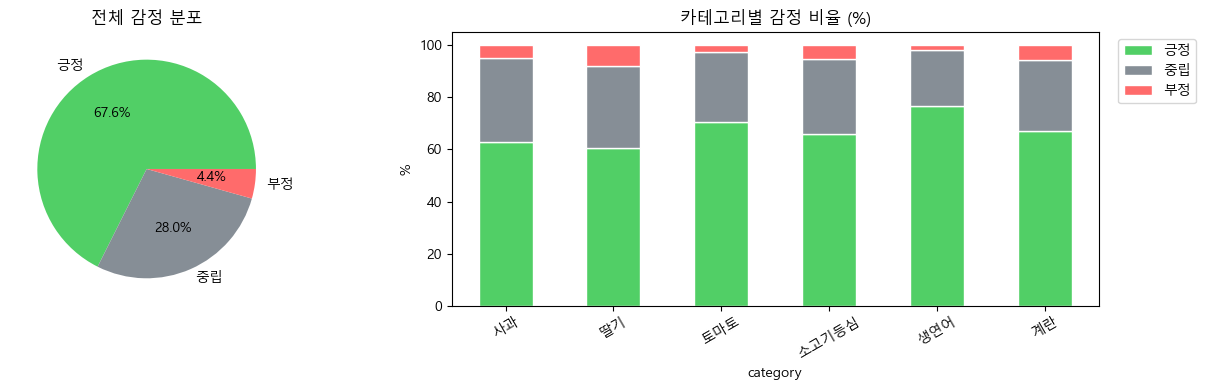

sentiment    긍정    중립   부정
category                  
사과         63.0  32.2  4.8
딸기         60.5  31.7  7.8
토마토        70.6  26.7  2.6
소고기등심      66.1  28.6  5.4
생연어        76.7  21.4  1.9
계란         67.2  27.0  5.8


In [37]:
# 감성 분포
# 전체 감성
sent_counts = df['sentiment'].value_counts()
# 카테고리 감성
sent_pivot = pd.crosstab(df['category'], df['sentiment'], normalize='index') * 100
sent_pivot = sent_pivot.loc[['사과','딸기','토마토','소고기등심','생연어','계란']]
for col in ['긍정','중립','부정']:
    if col not in sent_pivot.columns: sent_pivot[col] = 0
sent_pivot = sent_pivot[['긍정','중립','부정']]

# 감성 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].pie(sent_counts.values, labels=sent_counts.index, autopct='%.1f%%',
            colors=['#51cf66','#868e96','#ff6b6b'])
axes[0].set_title('전체 감정 분포')

sent_pivot.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#51cf66','#868e96','#ff6b6b'], edgecolor='white')
axes[1].set_title('카테고리별 감정 비율 (%)'); axes[1].set_ylabel('%')
axes[1].legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print(sent_pivot.round(1).to_string())

평가축 히트맵: 카테고리별 소비자 관심 축 차이 비교


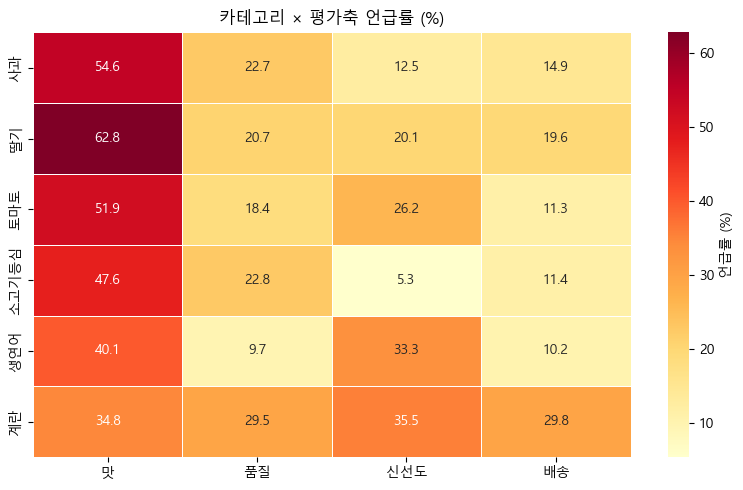

             맛    품질   신선도    배송
category                        
사과        54.6  22.7  12.5  14.9
딸기        62.8  20.7  20.1  19.6
토마토       52.0  18.4  26.2  11.3
소고기등심     47.6  22.8   5.3  11.4
생연어       40.1   9.7  33.3  10.2
계란        34.8  29.5  35.5  29.8


In [38]:
# 카테고리별 평가축
pivot = df.groupby('category')[[f'axis_{a}' for a in ['맛','품질','신선도','배송']]].mean() * 100
# 축 언급률
pivot.columns = ['맛','품질','신선도','배송']
pivot = pivot.loc[['사과','딸기','토마토','소고기등심','생연어','계란']]

# 히트맵
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label':'언급률 (%)'},
            linewidths=0.5, ax=ax)
ax.set_title('카테고리 × 평가축 언급률 (%)'); ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

print(pivot.round(1).to_string())

In [39]:
# 핵심 축 상위 단어
ignore_words = {
    '사과', '딸기', '토마토', '방울토마토', '고기', '소고기', '등심', '한우', '스테이크', '연어', '계란', '달걀', '과일',
    '환불', '반품', '실망', '가격', '가성비', '문의', '후기', '상태', '요번', '저번', '다음', '신경', '교환', '최악', '그냥',
    '구매', '구입', '박스', '포장', '배송', '주문', '정말', '진짜', '조금', '약간', '역시'
}

# 분석 대상 축
axis_targets = {
    '사과': ['맛', '품질'],
    '딸기': ['맛'],
    '토마토': ['맛', '신선도'],
    '소고기등심': ['맛', '품질'],
    '생연어': ['맛', '신선도'],
    '계란': ['맛', '신선도', '배송', '품질']
}

# 상위 단어 집계
rows = []
for category, axes in axis_targets.items():
    for axis in axes:
        reviews = df[(df['category'] == category) & (df[f'axis_{axis}'] == 1)]
        if len(reviews) == 0:
            continue
        word_freq = get_keyword_freq(reviews['review_text'], top_n=30)
        words = [(w, c) for w, c in word_freq.items() if w not in ignore_words][:5]
        rows.append({
            'category': category,
            'axis': axis,
            'review_count': len(reviews),
            'top_words': ' · '.join([f'{w}({c})' for w, c in words])
        })

pd.DataFrame(rows)

,category,axis,review_count,top_words
0,사과,맛,525,아침(47) · 껍질(44) · 당도(42) · 크기(41) · 식감(32)
1,사과,품질,218,크기(70) · 아침(27) · 껍질(27) · 사이즈(17) · 당도(15)
2,딸기,맛,404,금실(32) · 크기(29) · 당도(21) · 단맛(19) · 킹스베리(14)
3,토마토,맛,1039,크기(77) · 대추(75) · 식감(69) · 샐러드(63) · 스테비아(55)
4,토마토,신선도,524,대추(45) · 크기(38) · 건강(37) · 샐러드(36) · 단맛(26)
5,소고기등심,맛,857,기름(63) · 냄새(53) · 마블링(41) · 세일(40) · 소금(33)
6,소고기등심,품질,411,기름(33) · 등급(32) · 횡성(31) · 품질(30) · 세일(28)
7,생연어,맛,255,간장(27) · 소스(27) · 양파(26) · 초밥(23) · 와사비(19)
8,생연어,신선도,212,소스(20) · 비린내(19) · 식감(15) · 간장(14) · 덮밥(13)
9,계란,맛,139,노른자(25) · 항생제(23) · 소금(19) · 재료(17) · 요리(16)


부정 리뷰: 부정 리뷰 내 반복 불만 축과 키워드 확인 / 카테고리별 우선 대응 이슈 분리


In [40]:
# 부정 리뷰 불만 축 요약
# 부정 축 집계
rows = []
for category in ['사과','딸기','토마토','소고기등심','생연어','계란']:
    reviews = df[(df['category']==category) & (df['sentiment']=='부정')]
    if len(reviews)==0: continue
    # 축별 비중
    axes_pct = {a: reviews[f'axis_{a}'].mean()*100 for a in ['맛','품질','신선도','배송']}
    top2 = sorted(axes_pct.items(), key=lambda x:-x[1])[:2]
    rows.append({
        '카테고리': category,
        '부정리뷰수': len(reviews),
        '1위불만': f'{top2[0][0]} ({top2[0][1]:.0f}%)',
        '2위불만': f'{top2[1][0]} ({top2[1][1]:.0f}%)'
    })
pd.DataFrame(rows)

,카테고리,부정리뷰수,1위불만,2위불만
0,사과,46,품질 (43%),맛 (33%)
1,딸기,50,품질 (46%),신선도 (36%)
2,토마토,53,품질 (42%),배송 (32%)
3,소고기등심,97,맛 (43%),품질 (33%)
4,생연어,12,신선도 (58%),맛 (33%)
5,계란,23,배송 (61%),품질 (30%)


In [41]:
# 불만 원인 키워드
# 부정 대상 축
neg_axis_targets = {
    '사과': ['품질', '맛'],
    '딸기': ['품질', '신선도'],
    '토마토': ['품질', '배송'],
    '소고기등심': ['맛', '품질'],
    '생연어': ['신선도', '맛'],
    '계란': ['배송', '품질']
}

# 제외 단어
ignore_words = {
    '사과', '딸기', '토마토', '방울토마토', '고기', '소고기', '등심', '한우', '스테이크', '연어', '계란', '달걀', '과일',
    '환불', '반품', '실망', '가격', '가성비', '문의', '후기', '상태', '요번', '저번', '다음', '신경', '교환', '최악', '그냥'
}

# 불만 키워드 집계
rows = []
for category, axes in neg_axis_targets.items():
    for rank, axis in enumerate(axes, 1):
        reviews = df[(df['category'] == category) & (df['sentiment'] == '부정') & (df[f'axis_{axis}'] == 1)]
        if len(reviews) == 0:
            continue
        word_freq = get_keyword_freq(reviews['review_text'], top_n=20)
        words = [(w, c) for w, c in word_freq.items() if w not in ignore_words][:5]
        rows.append({
            'category': category,
            'rank': rank,
            'axis': axis,
            'review_count': len(reviews),
            'top_words': ' · '.join([f'{w}({c})' for w, c in words])
        })

pd.DataFrame(rows)

,category,rank,axis,review_count,top_words
0,사과,1,품질,20,당도(4) · 상처(3) · 크기(2) · 물건(2) · 기대(2)
1,사과,2,맛,15,당도(7) · 신맛(2) · 차이(2) · 푸석(2) · 물건(2)
2,딸기,1,품질,23,곰팡이(3) · 크기(3) · 금실(2) · 단맛(2) · 과육(2)
3,딸기,2,신선도,18,과육(3) · 곰팡이(3) · 킹스베리(2) · 냄새(2) · 크기(2)
4,토마토,1,품질,22,크기(4) · 꼭지(3) · 모양(3) · 곰팡이(3) · 용량(2)
5,토마토,2,배송,17,포장(6) · 상자(2) · 물렁(2) · 기대(2) · 방울(2)
6,소고기등심,1,맛,42,기름(8) · 레스팅(8) · 냄새(8) · 후추(6) · 구입(6)
7,소고기등심,2,품질,32,레스팅(8) · 기름(7) · 냄새(7) · 후추(6) · 등급(6)
8,생연어,1,신선도,7,비린내(6) · 흐믈(1) · 냉동(1) · 세일(1) · 브랜드(1)
9,생연어,2,맛,4,비린내(2) · 개심해요(1) · 회로(1) · 깍두기(1) · 소금(1)


In [42]:
# 긍정 리뷰 셀링 포인트
pos_ignore_words = ignore_words | {'구매', '배송', '주문', '정말', '진짜', '아주', '좋아요', '최고', '자주', '재구매'}

# 셀링 포인트 집계
rows = []
for category in ['사과', '딸기', '토마토', '소고기등심', '생연어', '계란']:
    positive_reviews = df[(df['category'] == category) & (df['sentiment'] == '긍정')]
    if len(positive_reviews) == 0:
        continue
    # 긍정 축 선택
    pos_axes = {a: positive_reviews[f'axis_{a}'].sum() for a in ['맛', '품질', '신선도', '배송']}
    best_axis = max(pos_axes, key=pos_axes.get)
    best_count = pos_axes[best_axis]
    axis_reviews = positive_reviews[positive_reviews[f'axis_{best_axis}'] == 1]
    word_freq = get_keyword_freq(axis_reviews['review_text'], top_n=20)
    words = [(w, c) for w, c in word_freq.items() if w not in pos_ignore_words][:5]
    rows.append({
        'category': category,
        'best_axis': best_axis,
        'mention_count': best_count,
        'keywords': ' · '.join([w for w, c in words])
    })

pd.DataFrame(rows)

,category,best_axis,mention_count,keywords
0,사과,맛,398,아침 · 껍질 · 크기 · 식감 · 포장
1,딸기,맛,291,금실 · 크기 · 포장 · 단맛 · 당도
2,토마토,맛,866,크기 · 대추 · 샐러드 · 식감 · 요리
3,소고기등심,맛,720,기름 · 냄새 · 세일 · 소금 · 마블링
4,생연어,맛,233,소스 · 간장 · 양파 · 초밥 · 와사비
5,계란,신선도,133,노른자 · 크기 · 항생제 · 신선도 · 요리


In [43]:
# 불만 원인 키워드
# 부정 대상 축
neg_axis_targets = {
    '사과': ['품질', '맛'],
    '딸기': ['품질', '신선도'],
    '토마토': ['품질', '배송'],
    '소고기등심': ['맛', '품질'],
    '생연어': ['신선도', '맛'],
    '계란': ['배송', '품질']
}

# 제외 단어
ignore_words = {
    '사과', '딸기', '토마토', '방울토마토', '고기', '소고기', '등심', '한우', '스테이크', '연어', '계란', '달걀', '과일',
    '환불', '반품', '실망', '가격', '가성비', '문의', '후기', '상태', '요번', '저번', '다음', '신경', '교환', '최악', '그냥'
}

# 불만 키워드 집계
rows = []
for category, axes in neg_axis_targets.items():
    for rank, axis in enumerate(axes, 1):
        reviews = df[(df['category'] == category) & (df['sentiment'] == '부정') & (df[f'axis_{axis}'] == 1)]
        if len(reviews) == 0:
            continue
        word_freq = get_keyword_freq(reviews['review_text'], top_n=20)
        words = [(w, c) for w, c in word_freq.items() if w not in ignore_words][:5]
        rows.append({
            'category': category,
            'rank': rank,
            'axis': axis,
            'review_count': len(reviews),
            'top_words': ' · '.join([f'{w}({c})' for w, c in words])
        })

pd.DataFrame(rows)

,category,rank,axis,review_count,top_words
0,사과,1,품질,20,당도(4) · 상처(3) · 크기(2) · 물건(2) · 기대(2)
1,사과,2,맛,15,당도(7) · 신맛(2) · 차이(2) · 푸석(2) · 물건(2)
2,딸기,1,품질,23,곰팡이(3) · 크기(3) · 금실(2) · 단맛(2) · 과육(2)
3,딸기,2,신선도,18,과육(3) · 곰팡이(3) · 킹스베리(2) · 냄새(2) · 크기(2)
4,토마토,1,품질,22,크기(4) · 꼭지(3) · 모양(3) · 곰팡이(3) · 용량(2)
5,토마토,2,배송,17,포장(6) · 상자(2) · 물렁(2) · 기대(2) · 방울(2)
6,소고기등심,1,맛,42,기름(8) · 레스팅(8) · 냄새(8) · 후추(6) · 구입(6)
7,소고기등심,2,품질,32,레스팅(8) · 기름(7) · 냄새(7) · 후추(6) · 등급(6)
8,생연어,1,신선도,7,비린내(6) · 흐믈(1) · 냉동(1) · 세일(1) · 브랜드(1)
9,생연어,2,맛,4,비린내(2) · 개심해요(1) · 회로(1) · 깍두기(1) · 소금(1)


### 6. 토마토 세부 유형

일반·방울·스테비아 유형별 평가축 차이 확인
표본 30건 이상 subtype 기준 워드클라우드 생성


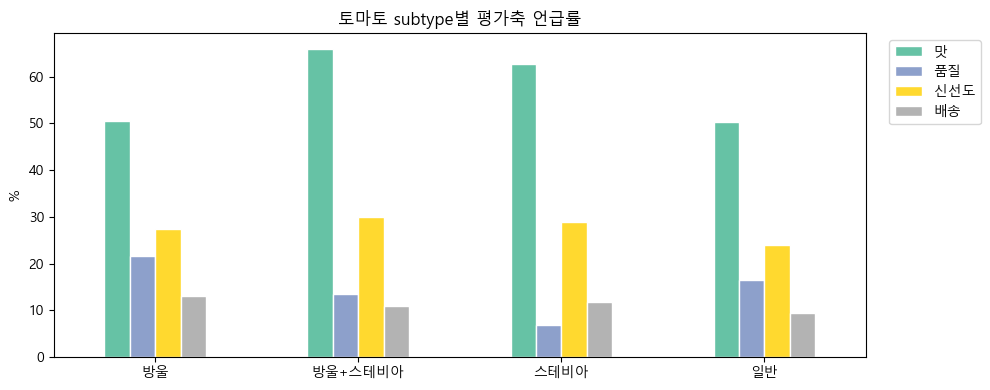

            맛    품질   신선도    배송
subtype                        
방울       50.6  21.6  27.4  13.0
방울+스테비아  66.0  13.6  29.9  10.9
스테비아     62.7   6.8  28.8  11.9
일반       50.3  16.6  24.1   9.4


In [44]:
# 토마토 세부 유형 평가축
tomato = df[df['category']=='토마토']
# 세부 유형 축 언급률
type_axis = tomato.groupby('subtype')[[f'axis_{a}' for a in ['맛','품질','신선도','배송']]].mean() * 100
type_axis.columns = ['맛','품질','신선도','배송']

# 세부 유형 시각화
fig, ax = plt.subplots(figsize=(10, 4))
type_axis.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title('토마토 subtype별 평가축 언급률')
ax.set_ylabel('%'); ax.set_xlabel('')
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

print(type_axis.round(1).to_string())

토마토 리뷰 크기: 토마토 카테고리 표본 수 확인


In [45]:
tomato = df[df['category'] == '토마토'].copy()
tomato.shape

(2000, 22)

In [46]:
# 토마토 세부 유형 분포: 세부 유형별 리뷰 수 비교
tomato['subtype'].value_counts()

subtype
방울         943
일반         851
방울+스테비아    147
스테비아        59
Name: count, dtype: int64

워드클라우드 대상: 표본 30건 이상 subtype 사용


In [47]:
type_counts = tomato['subtype'].value_counts()
valid_types = type_counts[type_counts >= 30].index.tolist()
valid_types

['방울', '일반', '방울+스테비아', '스테비아']

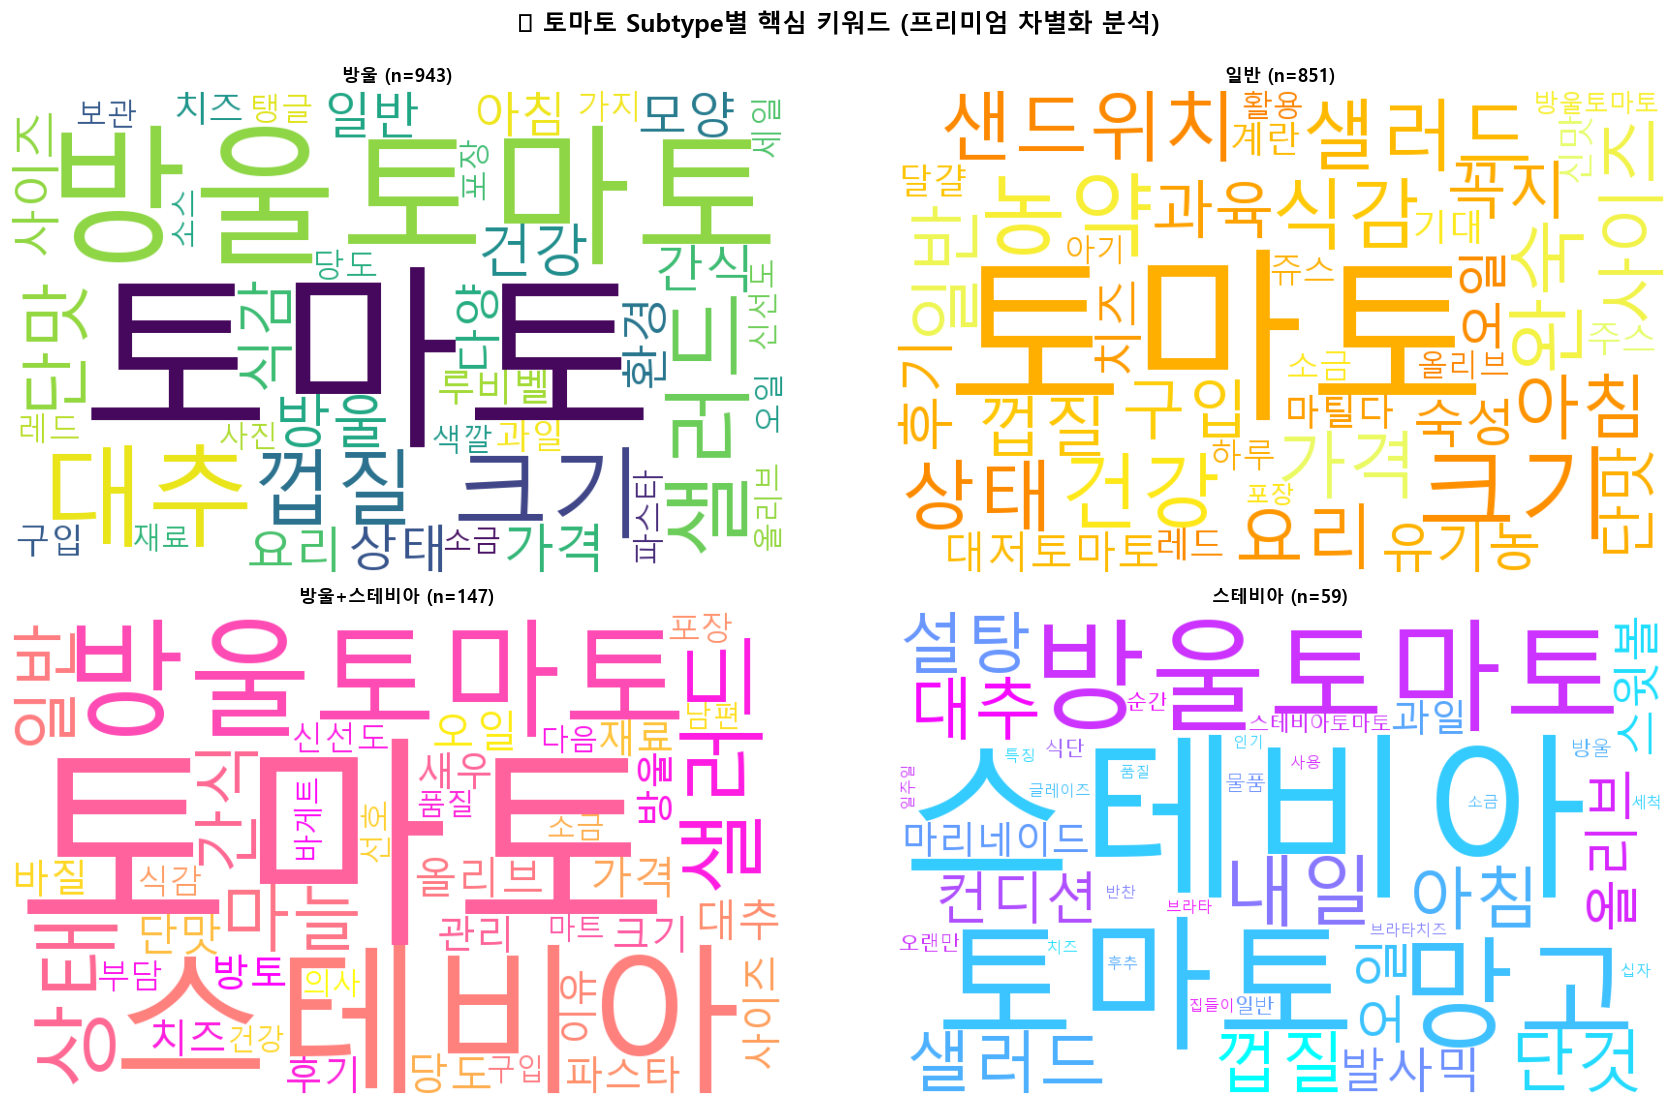

In [48]:
# 워드클라우드 함수
os.makedirs('output', exist_ok=True)

def make_wordcloud(freq_dict, ax, title, cmap='viridis'):
    if not freq_dict:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=20)
        ax.axis('off')
        return
    wc = WordCloud(
        font_path=font_path, width=800, height=500,
        background_color='white', colormap=cmap,
        max_words=50, relative_scaling=0.5, prefer_horizontal=0.9
    ).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

# 토마토 세부 유형 워드클라우드
# 세부 유형 표본
tomato = df[df['category'] == '토마토'].copy()
type_counts = tomato['subtype'].value_counts()
valid_types = type_counts[type_counts >= 30].index.tolist()

# 세부 유형 워드클라우드
# subplot 기준
n = len(valid_types)
ncol = 2
nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 5.5*nrow))
if nrow == 1:
    axes = np.array([axes])
fig.suptitle('🍅 토마토 Subtype별 핵심 키워드 (프리미엄 차별화 분석)',
             fontsize=18, fontweight='bold', y=1.0)

# 워드클라우드 생성
type_keywords = {}
type_cmap = ['viridis', 'Wistia', 'spring', 'cool']

for idx, tomato_type in enumerate(valid_types):
    type_reviews = tomato[tomato['subtype'] == tomato_type]
    word_freq = get_keyword_freq(type_reviews['review_text'], top_n=40)
    type_keywords[tomato_type] = word_freq
    
    ax = axes.flat[idx]
    make_wordcloud(word_freq, ax, f'{tomato_type} (n={len(type_reviews)})', cmap=type_cmap[idx % len(type_cmap)])
    top5 = list(word_freq.items())[:5]

# 빈 영역 숨김
for idx in range(len(valid_types), nrow*ncol):
    axes.flat[idx].axis('off')

plt.tight_layout()
plt.savefig('output/04_tomato_subtype_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


In [49]:
# 세부 유형 차별 키워드
type_keywords = {}

# 세부 유형별 빈도
for tomato_type in valid_types:
    type_reviews = tomato[tomato['subtype'] == tomato_type]
    word_freq = get_keyword_freq(type_reviews['review_text'], top_n=40)
    type_keywords[tomato_type] = word_freq

# 차별 점수
diff_words = []
if len(type_keywords) >= 2:
    all_words = set()
    for word_dict in type_keywords.values():
        all_words.update(word_dict.keys())

    # 정규화 빈도
    rate_by_type = {}
    for tomato_type, words in type_keywords.items():
        total = sum(words.values())
        rate_by_type[tomato_type] = {w: words.get(w, 0) / total for w in all_words}

    for tomato_type in type_keywords.keys():
        others = [other for other in type_keywords.keys() if other != tomato_type]
        word_scores = {}
        for w in all_words:
            self_freq = rate_by_type[tomato_type][w]
            others_avg = np.mean([rate_by_type[o][w] for o in others])
            if self_freq > 0:
                word_scores[w] = self_freq - others_avg

        for word, score in sorted(word_scores.items(), key=lambda x: -x[1])[:10]:
            if score > 0:
                diff_words.append({
                    'subtype': tomato_type,
                    'word': word,
                    'diff_score': round(score * 1000, 2),
                    'count': type_keywords[tomato_type].get(word, 0)
                })

pd.DataFrame(diff_words)

,subtype,word,diff_score,count
0,방울,방울토마토,76.93,197
1,방울,대추,44.04,90
2,방울,크기,28.71,71
3,방울,껍질,18.84,51
4,방울,모양,15.88,24
5,방울,환경,14.56,22
6,방울,루비벨,13.90,21
7,방울,다양,13.90,21
8,방울,토마토,12.63,371
9,방울,단맛,12.34,34


### 7. 통계 검정

카테고리별 평가축 차이 유의성 확인
카이제곱·Cramer's V 기준 차이 크기 점검


In [50]:
# 카이제곱 검정
axes_list = ['맛', '품질', '신선도', '배송']

# 검정 결과
chi2_results = []

# 축별 검정
for axis in axes_list:
    axis_col = f'axis_{axis}'
    cross_tab = pd.crosstab(df['category'], df[axis_col])
    chi2, p_value, _, _ = chi2_contingency(cross_tab)
    total_count = cross_tab.values.sum()
    cramers_v = np.sqrt(chi2 / (total_count * (min(cross_tab.shape) - 1)))

    chi2_results.append({
        '축': axis,
        'χ²': round(chi2, 2),
        'p-value': f'{p_value:.2e}',
        "Cramér\'s V": round(cramers_v, 3),
        '판정': '유의' if p_value < 0.05 else '비유의'
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df

,축,χ²,p-value,Cramér's V,판정
0,맛,119.71,3.61e-24,0.136,유의
1,품질,79.27,1.19e-15,0.111,유의
2,신선도,468.81,4.30e-99,0.270,유의
3,배송,131.35,1.23e-26,0.143,유의


1차 정리: 과일 맛·품질, 연어 신선도, 계란 배송 리스크 구조


In [51]:
# 검증 기준
categories = ['사과', '딸기', '토마토', '소고기등심', '생연어', '계란']
axes_list = ['맛', '품질', '신선도', '배송']


### 8. LLM 검증

저장된 LLM 검증본 기준 키워드 분류 품질 확인
sample_idx 병합 후 축별 혼동행렬·F1 비교


LLM 검증본 기준: 비용·시간·응답 변동성 방지용 저장본 사용


In [52]:
# LLM 검증본 매칭
if df_llm is None:
    raise FileNotFoundError('kurly_reviews_llm_validation.csv 없음')

# sample_idx 기준
base_for_llm = df.reset_index().rename(columns={'index': 'sample_idx'})

# 검증 컬럼
llm_cols = ['sample_idx'] + [f'llm_axis_{a}' for a in axes_list] + ['llm_sentiment']
missing_cols = [c for c in llm_cols if c not in df_llm.columns]
if missing_cols:
    raise ValueError(f'LLM 검증 컬럼 누락: {missing_cols}')

# 검증본 병합
llm_compare = base_for_llm.merge(df_llm[llm_cols], on='sample_idx', how='inner')
llm_compare.shape


(6441, 28)

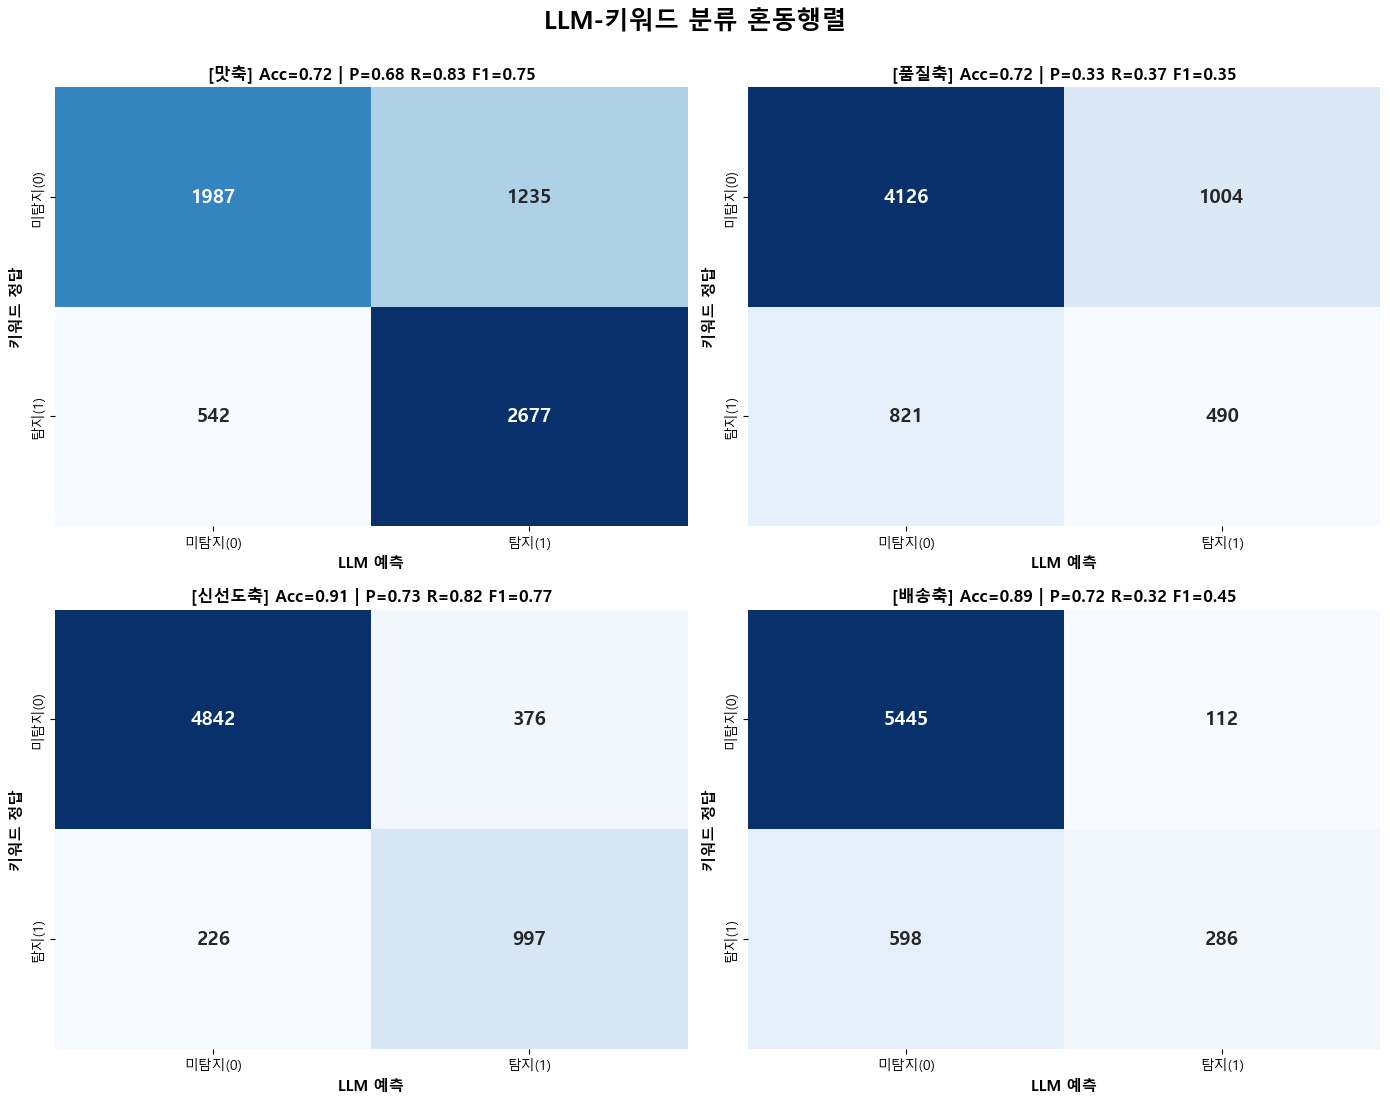

,축,정확도,정밀도,재현율,F1,LLM 추가 포착률(%),키워드 단독 포착률(%),TN,FP,FN,TP
0,맛,0.724,0.684,0.832,0.751,19.2,8.4,1987,1235,542,2677
1,품질,0.717,0.328,0.374,0.349,15.6,12.7,4126,1004,821,490
2,신선도,0.907,0.726,0.815,0.768,5.8,3.5,4842,376,226,997
3,배송,0.890,0.719,0.324,0.446,1.7,9.3,5445,112,598,286


In [53]:
os.makedirs('output', exist_ok=True)

# 혼동행렬 화면
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('LLM-키워드 분류 혼동행렬', fontsize=18, fontweight='bold', y=1.0)

# 축별 지표
metrics_summary = []
for idx, axis in enumerate(axes_list):
    y_true = llm_compare[f'axis_{axis}'].fillna(0).astype(int)
    y_pred = llm_compare[f'llm_axis_{axis}'].fillna(0).astype(int)

    # 분류 지표
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], average=None, zero_division=0
    )
    accuracy = (y_true == y_pred).mean()

    metrics_summary.append({
        '축': axis,
        '정확도': round(accuracy, 3),
        '정밀도': round(precision[1], 3),
        '재현율': round(recall[1], 3),
        'F1': round(f1[1], 3),
        'LLM 추가 포착률(%)': round(((y_true == 0) & (y_pred == 1)).mean() * 100, 1),
        '키워드 단독 포착률(%)': round(((y_true == 1) & (y_pred == 0)).mean() * 100, 1),
        'TN': cm[0, 0], 'FP': cm[0, 1], 'FN': cm[1, 0], 'TP': cm[1, 1],
    })

    # 혼동행렬 시각화
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
        xticklabels=['미탐지(0)', '탐지(1)'],
        yticklabels=['미탐지(0)', '탐지(1)'],
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    ax.set_xlabel('LLM 예측', fontweight='bold', fontsize=11)
    ax.set_ylabel('키워드 정답', fontweight='bold', fontsize=11)
    ax.set_title(
        f'[{axis}축] Acc={accuracy:.2f} | P={precision[1]:.2f} R={recall[1]:.2f} F1={f1[1]:.2f}',
        fontweight='bold', fontsize=12
    )

plt.tight_layout()
plt.savefig('output/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 검증 요약
metrics_df = pd.DataFrame(metrics_summary)
sentiment_agreement = (llm_compare['sentiment'] == llm_compare['llm_sentiment']).mean() * 100
metrics_df


In [54]:
# 감성 일치율: 키워드 감성과 LLM 감성 라벨 비교
round(sentiment_agreement, 1)

np.float64(70.2)

In [55]:
# 축별 검증 지표: 정확도·정밀도·재현율·F1 비교
metrics_df

,축,정확도,정밀도,재현율,F1,LLM 추가 포착률(%),키워드 단독 포착률(%),TN,FP,FN,TP
0,맛,0.724,0.684,0.832,0.751,19.2,8.4,1987,1235,542,2677
1,품질,0.717,0.328,0.374,0.349,15.6,12.7,4126,1004,821,490
2,신선도,0.907,0.726,0.815,0.768,5.8,3.5,4842,376,226,997
3,배송,0.890,0.719,0.324,0.446,1.7,9.3,5445,112,598,286


,카테고리,검증 리뷰 수,축 평균 일치율,감성 일치율
3,생연어,636,84.0,75.2
5,토마토,2000,82.0,71.8
4,소고기등심,1800,80.3,70.6
0,계란,400,80.2,74.8
2,사과,962,79.7,64.8
1,딸기,643,78.7,64.9


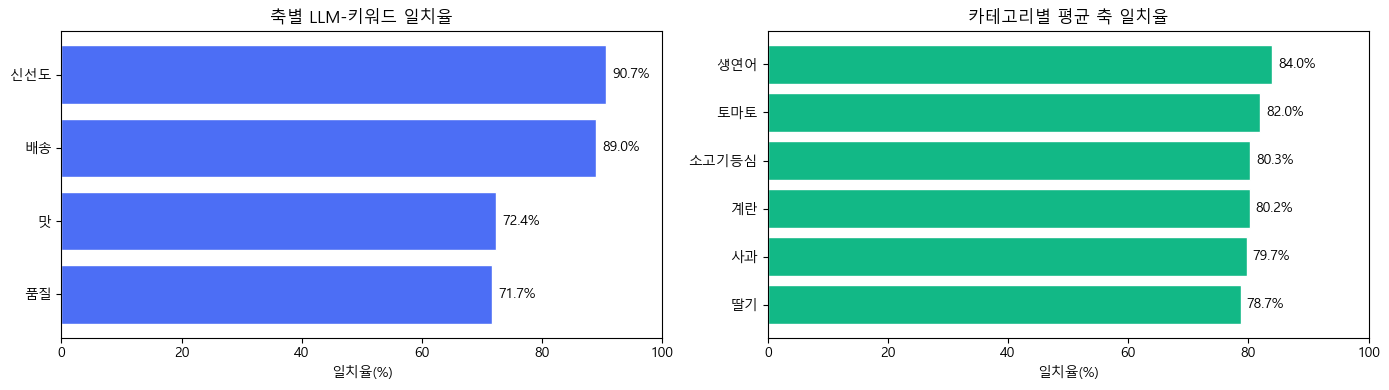

In [56]:
# LLM 검증 요약
# 축별 일치율
llm_axis_summary = metrics_df.rename(columns={
    '축': 'axis',
    '정확도': 'agreement_rate',
}).copy()
llm_axis_summary['agreement_rate'] = llm_axis_summary['agreement_rate'] * 100

# 카테고리 일치율
category_rows = []
for category, group in llm_compare.groupby('category'):
    axis_agreement_avg = np.mean([
        (group[f'axis_{a}'].astype(int) == g[f'llm_axis_{a}'].astype(int)).mean() * 100
        for a in axes_list
    ])
    category_rows.append({
        '카테고리': category,
        '검증 리뷰 수': len(group),
        '축 평균 일치율': axis_agreement_avg,
        '감성 일치율': (group['sentiment'] == group['llm_sentiment']).mean() * 100,
    })

llm_category_summary = pd.DataFrame(category_rows).sort_values('축 평균 일치율', ascending=False).round(1)
display(llm_category_summary)

# 일치율 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axis_plot = llm_axis_summary.sort_values('agreement_rate', ascending=True)
axes[0].barh(axis_plot['axis'], axis_plot['agreement_rate'], color='#4c6ef5', edgecolor='white')
axes[0].set_xlim(0, 100)
axes[0].set_title('축별 LLM-키워드 일치율')
axes[0].set_xlabel('일치율(%)')
for i, v in enumerate(axis_plot['agreement_rate']):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center')

cat_plot = llm_category_summary.sort_values('축 평균 일치율', ascending=True)
axes[1].barh(cat_plot['카테고리'], cat_plot['축 평균 일치율'], color='#12b886', edgecolor='white')
axes[1].set_xlim(0, 100)
axes[1].set_title('카테고리별 평균 축 일치율')
axes[1].set_xlabel('일치율(%)')
for i, v in enumerate(cat_plot['축 평균 일치율']):
    axes[1].text(v + 1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()


### 9. 운영 우선순위

부정률·리뷰 비중·카테고리 중요도 결합
Priority Index 기준 MD·CX 대응 순서 정리


In [57]:
# 운영 우선순위
# 중요도 가중치
importance = {
    '계란': 1.00,
    '딸기': 0.90,
    '생연어': 0.85,
    '토마토': 0.80,
    '소고기등심': 0.70,
    '사과': 0.60,
}

# 부정률·리뷰 비중
neg_ratio = df.groupby('category')['sentiment'].apply(lambda x: (x == '부정').mean())
review_share = df.groupby('category').size() / len(df)
importance_s = pd.Series(importance)
# Priority Index
raw_score = neg_ratio * review_share * importance_s
priority_index = (raw_score / raw_score.max() * 100).round(1)

# 우선순위 요약
priority_rows = []
neg_df = df[df['sentiment'] == '부정']
for category in priority_index.sort_values(ascending=False).index:
    neg_reviews = neg_df[neg_df['category'] == category]
    axis_pct = {a: neg_reviews[f'axis_{a}'].mean() * 100 if len(neg_reviews) else 0 for a in axes_list}
    top2 = sorted(axis_pct.items(), key=lambda x: -x[1])[:2]
    tier = 'P1' if priority_index[category] >= 80 else ('P2' if priority_index[category] >= 50 else 'P3')
    priority_rows.append({
        'category': category,
        '운영 우선순위 지수': priority_index[category],
        'tier': tier,
        '부정률': neg_ratio[category] * 100,
        '리뷰 비중': review_share[category] * 100,
        '부정 리뷰 수': len(neg_reviews),
        '상위 부정 축': ' / '.join([f'{axis} {pct:.1f}%' for axis, pct in top2])
    })

priority_summary = pd.DataFrame(priority_rows).round(1)
display(priority_summary)


,category,운영 우선순위 지수,tier,부정률,리뷰 비중,부정 리뷰 수,상위 부정 축
0,소고기등심,100.0,P1,5.4,27.9,97,맛 43.3% / 품질 33.0%
1,딸기,66.3,P2,7.8,10.0,50,품질 46.0% / 신선도 36.0%
2,토마토,62.4,P2,2.6,31.1,53,품질 41.5% / 배송 32.1%
3,사과,40.6,P3,4.8,14.9,46,품질 43.5% / 맛 32.6%
4,계란,33.9,P3,5.8,6.2,23,배송 60.9% / 품질 30.4%
5,생연어,15.0,P3,1.9,9.9,12,신선도 58.3% / 맛 33.3%


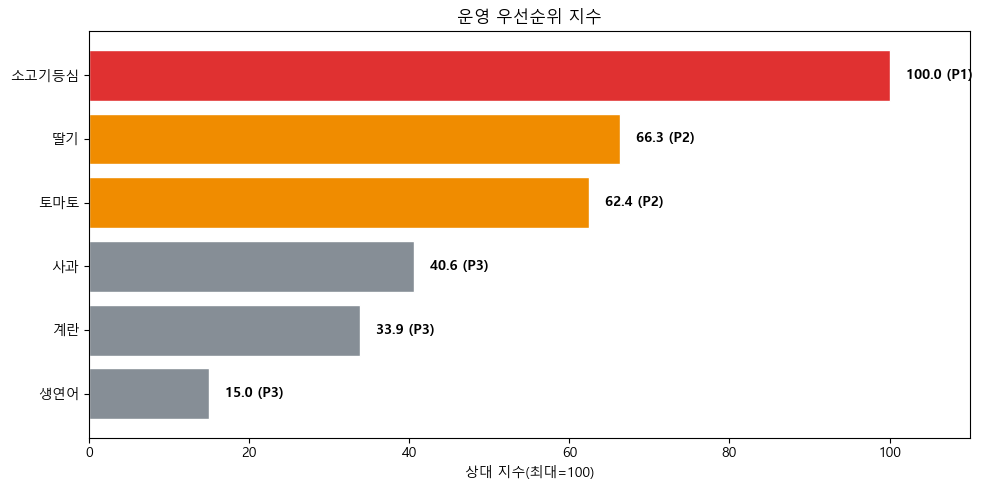

In [58]:
# 우선순위 시각화
tier_color = {'P1': '#e03131', 'P2': '#f08c00', 'P3': '#868e96'}
# 표시 순서
plot_df = priority_summary.sort_values('운영 우선순위 지수', ascending=True)

# 우선순위 그래프
fig, ax = plt.subplots(figsize=(10, 5))
colors = plot_df['tier'].map(tier_color)
ax.barh(plot_df['category'], plot_df['운영 우선순위 지수'], color=colors, edgecolor='white')
ax.set_xlim(0, 110)
ax.set_title('운영 우선순위 지수')
ax.set_xlabel('상대 지수(최대=100)')
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(row['운영 우선순위 지수'] + 2, i, f"{row['운영 우선순위 지수']:.1f} ({row['tier']})", va='center', fontweight='bold')
plt.tight_layout()
plt.show()


대시보드 연결: 4축 분류, LLM 검증, Priority 결과 반영 기준
